<a href="https://colab.research.google.com/github/Lakshman3556/Deep_Learning/blob/main/DL_week9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Implement Guided Backpropagation to discover which input pixels influence the perceptron.(Give all the intermediate steps and write your observations)

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models

# Load CIFAR-10
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalize
X_train = X_train.astype('float32') / 255.
X_test = X_test.astype('float32') / 255.

# Build CNN
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test))

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 43ms/step - accuracy: 0.4880 - loss: 1.4350 - val_accuracy: 0.5918 - val_loss: 1.1704
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 61s 39ms/step - accuracy: 0.6192 - loss: 1.0890 - val_accuracy: 0.6027 - val_loss: 1.1449
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 39ms/step - accuracy: 0.6611 - loss: 0.9668 - val_accuracy: 0.6666 - val_loss: 0.9685
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 38ms/step - accuracy: 0.6919 - loss: 0.8851 - val_accuracy: 0.6652 - val_loss: 0.9692
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 58s 37ms/step - accuracy: 0.7172 - loss: 0.8135 - val_accuracy: 0.6872 - val_loss: 0.9045


In [17]:
@tf.custom_gradient
def guided_relu(x):
    def grad(dy):
        return dy * tf.cast(dy > 0, "float32") * tf.cast(x > 0, "float32")
    return tf.nn.relu(x), grad

In [18]:
def build_guided_model(original_model):
    guided_model = tf.keras.models.clone_model(original_model)

    for layer in guided_model.layers:
        if hasattr(layer, 'activation') and layer.activation == tf.keras.activations.relu:
            layer.activation = guided_relu

    guided_model.set_weights(original_model.get_weights())
    return guided_model

guided_model = build_guided_model(model)

In [7]:
def guided_backprop(model, img, class_index):
    img = tf.convert_to_tensor(img)
    img = tf.expand_dims(img, axis=0)

    with tf.GradientTape() as tape:
        tape.watch(img)
        preds = model(img)
        loss = preds[:, class_index]

    grads = tape.gradient(loss, img)
    return grads[0].numpy()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step


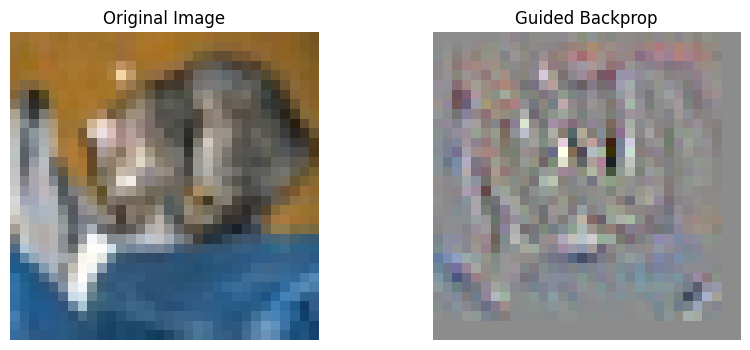

In [5]:
# Pick sample image
idx = 0
img = X_test[idx]

# Predict class
pred_class = np.argmax(model.predict(img.reshape(1,32,32,3)))

# Get gradients
grads = guided_backprop(guided_model, img, pred_class)

# Normalize
grads = (grads - grads.min()) / (grads.max() - grads.min())

# Plot
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(grads)
plt.title("Guided Backprop")
plt.axis('off')

plt.show()

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 178s 441ms/step - accuracy: 0.5209 - loss: 1.3416 - val_accuracy: 0.1947 - val_loss: 2.7419
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 170s 434ms/step - accuracy: 0.6756 - loss: 0.9273 - val_accuracy: 0.6497 - val_loss: 0.9944
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 173s 441ms/step - accuracy: 0.7341 - loss: 0.7562 - val_accuracy: 0.6640 - val_loss: 0.9643
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 202s 440ms/step - accuracy: 0.7703 - loss: 0.6527 - val_accuracy: 0.7127 - val_loss: 0.8526
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 200s 436ms/step - accuracy: 0.7984 - loss: 0.5753 - val_accuracy: 0.7261 - val_loss: 0.7903
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 201s 435ms/step - accuracy: 0.8226 - loss: 0.5038 - val_accuracy: 0.7331 - val_loss: 0.8017
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 205s 444ms/step - accuracy: 0.8433 - loss: 0.4488 - val_accuracy: 0.7493 - val_loss: 0.7737
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 199s 435ms/step - accuracy: 0.8627 -

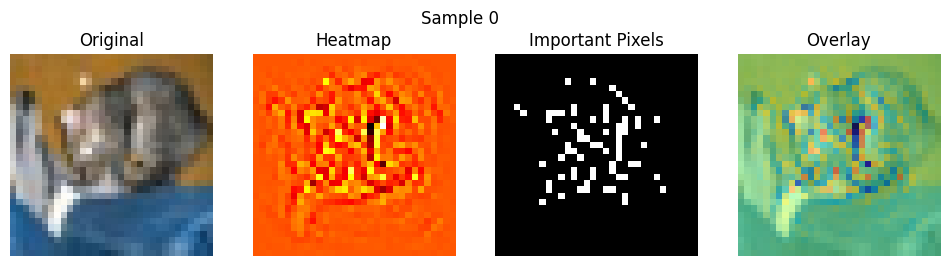

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


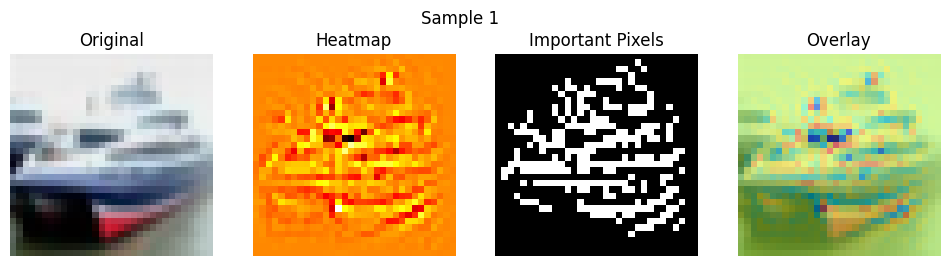

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


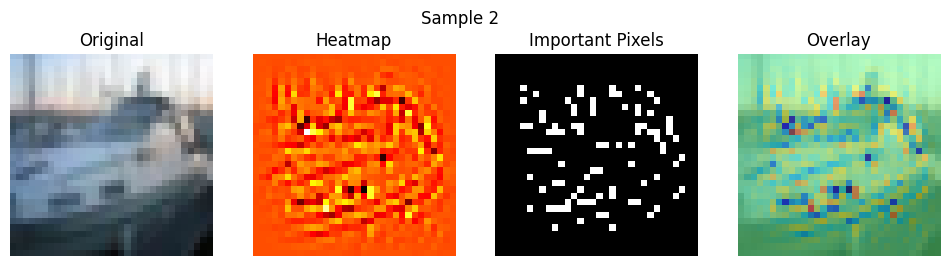

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


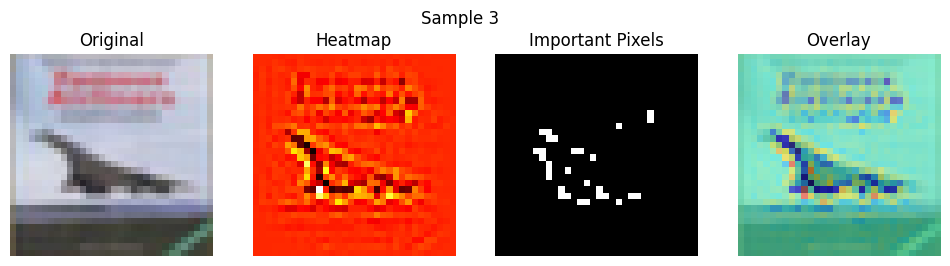

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


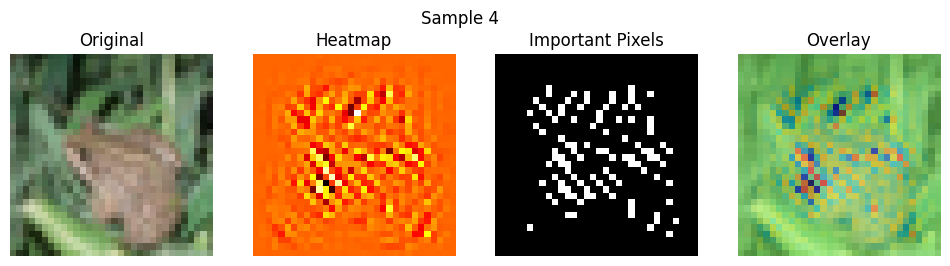

In [6]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models

# =========================
# 1. LOAD DATA
# =========================
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

X_train = X_train.astype('float32') / 255.
X_test = X_test.astype('float32') / 255.

# =========================
# 2. BUILD IMPROVED CNN
# =========================
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# =========================
# 3. TRAIN MODEL
# =========================
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=128,
    validation_data=(X_test, y_test)
)

# =========================
# 4. GUIDED RELU
# =========================
@tf.custom_gradient
def guided_relu(x):
    def grad(dy):
        return dy * tf.cast(dy > 0, "float32") * tf.cast(x > 0, "float32")
    return tf.nn.relu(x), grad

# =========================
# 5. BUILD GUIDED MODEL
# =========================
def build_guided_model(original_model):
    guided_model = tf.keras.models.clone_model(original_model)

    for layer in guided_model.layers:
        if hasattr(layer, 'activation') and layer.activation == tf.keras.activations.relu:
            layer.activation = guided_relu

    guided_model.set_weights(original_model.get_weights())
    return guided_model

guided_model = build_guided_model(model)

# =========================
# 6. GUIDED BACKPROP FUNCTION
# =========================
def guided_backprop(model, img, class_index):
    img = tf.convert_to_tensor(img)
    img = tf.expand_dims(img, axis=0)

    with tf.GradientTape() as tape:
        tape.watch(img)
        preds = model(img)
        loss = preds[:, class_index]

    grads = tape.gradient(loss, img)
    return grads[0].numpy()

# =========================
# 7. VISUALIZATION FUNCTION
# =========================
def visualize_results(img, grads, idx):
    grads_gray = np.mean(grads, axis=-1)

    # Normalize
    grads_gray = (grads_gray - grads_gray.min()) / (grads_gray.max() - grads_gray.min())

    # Threshold
    threshold = 0.6
    mask = grads_gray > threshold

    plt.figure(figsize=(12,3))

    # Original
    plt.subplot(1,4,1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis('off')

    # Heatmap
    plt.subplot(1,4,2)
    plt.imshow(grads_gray, cmap='hot')
    plt.title("Heatmap")
    plt.axis('off')

    # Thresholded
    plt.subplot(1,4,3)
    plt.imshow(mask, cmap='gray')
    plt.title("Important Pixels")
    plt.axis('off')

    # Overlay
    plt.subplot(1,4,4)
    plt.imshow(img)
    plt.imshow(grads_gray, cmap='jet', alpha=0.5)
    plt.title("Overlay")
    plt.axis('off')

    plt.suptitle(f"Sample {idx}")
    plt.show()

# =========================
# 8. RUN ON MULTIPLE IMAGES
# =========================
for i in range(5):
    img = X_test[i]

    pred_class = np.argmax(model.predict(img.reshape(1,32,32,3)))

    grads = guided_backprop(guided_model, img, pred_class)

    visualize_results(img, grads, i)

In [1]:
def grad_cam(model, img, layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(layer_name).output, model.output]
    )

    img = tf.expand_dims(img, axis=0)

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img)
        class_index = tf.argmax(predictions[0])
        loss = predictions[:, class_index]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)

    return heatmap.numpy()

In [2]:
def display_gradcam(img, heatmap):
    heatmap = np.uint8(255 * heatmap)

    plt.figure(figsize=(10,3))

    # Original
    plt.subplot(1,3,1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis('off')

    # Heatmap
    plt.subplot(1,3,2)
    plt.imshow(heatmap, cmap='jet')
    plt.title("Grad-CAM")
    plt.axis('off')

    # Overlay
    plt.subplot(1,3,3)
    plt.imshow(img)
    plt.imshow(heatmap, cmap='jet', alpha=0.5)
    plt.title("Overlay")
    plt.axis('off')

    plt.show()

In [21]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models

# =========================
# 1. LOAD DATA
# =========================
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

X_train = X_train.astype('float32') / 255.
X_test = X_test.astype('float32') / 255.

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

# =========================
# 2. BUILD MODEL
# =========================
model = models.Sequential([
    tf.keras.Input(shape=(32,32,3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# =========================
# 3. TRAIN MODEL
# =========================
model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=128,
    validation_data=(X_test, y_test)
)

# =========================
# 4. AUTO SELECT LAST CONV LAYER
# =========================
last_conv_layer = None
for layer in model.layers[::-1]:
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer = layer.name
        break

print("Using last conv layer:", last_conv_layer)

# =========================
# 5. GRAD-CAM FUNCTION
# =========================
def grad_cam(model, img, layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(layer_name).output, model.output]
    )

    img = tf.expand_dims(img, axis=0)

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img)
        class_index = tf.argmax(predictions[0])
        loss = predictions[:, class_index]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)

    return heatmap.numpy()

# =========================
# 6. DISPLAY FUNCTION
# =========================
def display_gradcam(img, heatmap, pred_label, true_label):

    heatmap = np.uint8(255 * heatmap)

    plt.figure(figsize=(10,3))

    # Original
    plt.subplot(1,3,1)
    plt.imshow(img)
    plt.title(f"Original\nTrue: {true_label}")
    plt.axis('off')

    # Heatmap
    plt.subplot(1,3,2)
    plt.imshow(heatmap, cmap='jet')
    plt.title("Grad-CAM")
    plt.axis('off')

    # Overlay
    plt.subplot(1,3,3)
    plt.imshow(img)
    plt.imshow(heatmap, cmap='jet', alpha=0.5)
    plt.title(f"Pred: {pred_label}")
    plt.axis('off')

    plt.show()

# =========================
# 7. RUN ON TEST IMAGES
# =========================
for i in range(5):
    img = X_test[i]

    preds = model.predict(img.reshape(1,32,32,3))
    pred_class = np.argmax(preds[0])

    heatmap = grad_cam(model, img, last_conv_layer)

    display_gradcam(
        img,
        heatmap,
        class_names[pred_class],
        class_names[y_test[i][0]]
    )

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 171s 428ms/step - accuracy: 0.4942 - loss: 1.4109 - val_accuracy: 0.2928 - val_loss: 2.1316
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 164s 418ms/step - accuracy: 0.6618 - loss: 0.9573 - val_accuracy: 0.6524 - val_loss: 0.9840
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 204s 423ms/step - accuracy: 0.7261 - loss: 0.7828 - val_accuracy: 0.6649 - val_loss: 1.0041
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 165s 421ms/step - accuracy: 0.7656 - loss: 0.6735 - val_accuracy: 0.7121 - val_loss: 0.8265
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 166s 425ms/step - accuracy: 0.7953 - loss: 0.5873 - val_accuracy: 0.7265 - val_loss: 0.8033
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 209s 443ms/step - accuracy: 0.8177 - loss: 0.5212 - val_accuracy: 0.7241 - val_loss: 0.8034
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 197s 431ms/step - accuracy: 0.8402 - loss: 0.4574 - val_accuracy: 0.7392 - val_loss: 0.7813
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 168s 429ms/step - accuracy: 0.8564 -

AttributeError: The layer sequential_12 has never been called and thus has no defined output.